# Instrucciones

1. Gráficas deben ser con Seaborn (si existe ese tipo de gráfica, sino con matplotlib), lo más completas (ejes, título, legenda, etc.) posibles y bien formateadas visualmente.

2. Como analista de datos, tu misión es auditar el dataset adjunto para identificar patrones de comportamiento. Cada ejercicio tiene que aportar "conclusiones" respondiendo las preguntas y aportando las propias en función de cada resultado o gráfico.

3. Los prints de datos deben quedar visibles (usa round, saltos de línea, caracteres de separación, etc.)

4. Si no se dice lo contrario, el apartado correspondiente siempre usa el DataFrame original.

5. Se debe entregar el HTML

# Bloque 1: Carga y Auditoría inicial

__Dataset__: https://www.kaggle.com/datasets/miadul/e-commerce-sales-transactions-dataset/data

__En la misma celda de código__

1. Importación: Carga de librerías necesarias (Pandas, Matplotlib, Seaborn).
2. Exploración Inicial: Uso de .info() (mira el tipo de cada columna), .describe() y detección de nulos.
3. Clasificación y muestra de variables en 2 grupos, Numéricas y categóricas
4. Inspecciona con head las 5 primeras filas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_csv('ecommerce_sales_34500.csv')


print("--- Información General ---")
df.info()

print("\n--- Estadísticos Descriptivos ---")
display(df.describe())

print("\n--- Detección de Nulos ---")
print(df.isnull().sum())

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

print("\n" + "="*30)
print(f"Variables Numéricas ({len(numeric_cols)}):")
print(numeric_cols)

print(f"\nVariables Categóricas ({len(categorical_cols)}):")
print(categorical_cols)
print("="*30 + "\n")

print("--- Vista previa del Dataset ---")
display(df.head(5))

--- Información General ---
<class 'pandas.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  str    
 1   customer_id         34500 non-null  str    
 2   product_id          34500 non-null  str    
 3   category            34500 non-null  str    
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  str    
 8   order_date          34500 non-null  str    
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  str    
 11  returned            34500 non-null  str    
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 non-null  

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000



--- Detección de Nulos ---
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

Variables Numéricas (8):
['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age']

Variables Categóricas (9):
['order_id', 'customer_id', 'product_id', 'category', 'payment_method', 'order_date', 'region', 'returned', 'customer_gender']

--- Vista previa del Dataset ---


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


# Bloque 2: Análisis Univariante variables numéricas (1.5 pts)

Vamos a analizar las variables:
+ total_amount: Es la facturación total de cada venta.
+ profit_margin: El márgen de cada venta.
+ customer_age: El perfil demográfico del cliente.

__En celdas de código independientes:__

1. Calcular estadísticos de cada variable y mostrar: Media, std, Q1, Q2(mediana) Q3, IQR.

2. Crear histogramas con la línea de densidad (KDE) para las variables numéricas. Pintar sobre ellas la media y mediana, y sombrado con la zona Q1-Q3.

3. __Realiza una copia para no tocar el DF original__ de total_mount y profit_margin. Elimina todas las filas que supongan atípicos. Muestra cuantas filas se han eliminado y cuantas han quedado en el DF limpio.

4. Vuelve a crear los mismos histogramas que el punto 2 con estas variables limpias.

5. Responder en celda markdown: Comenta la forma de la distribución de 2 y 4. ¿Normal? ¿sesgo hacia izquierda/derecha?.

In [3]:
vars_study = ['total_amount', 'profit_margin', 'customer_age']

stats_dict = {}

for col in vars_study:
    q1 = df[col].quantile(0.25)
    q2 = df[col].median()
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    stats_dict[col] = {
        'Media': df[col].mean(),
        'Desv. Estándar': df[col].std(),
        'Q1 (P25)': q1,
        'Mediana (Q2)': q2,
        'Q3 (P75)': q3,
        'IQR': iqr
    }

stats_df = pd.DataFrame(stats_dict)
display(stats_df.round(2))

,total_amount,profit_margin,customer_age
Media,170.01,28.12,43.47
Desv. Estándar,357.50,53.35,14.98
Q1 (P25),19.71,1.50,31.00
Mediana (Q2),56.82,10.55,43.00
Q3 (P75),168.53,33.13,56.00
IQR,148.82,31.63,25.00


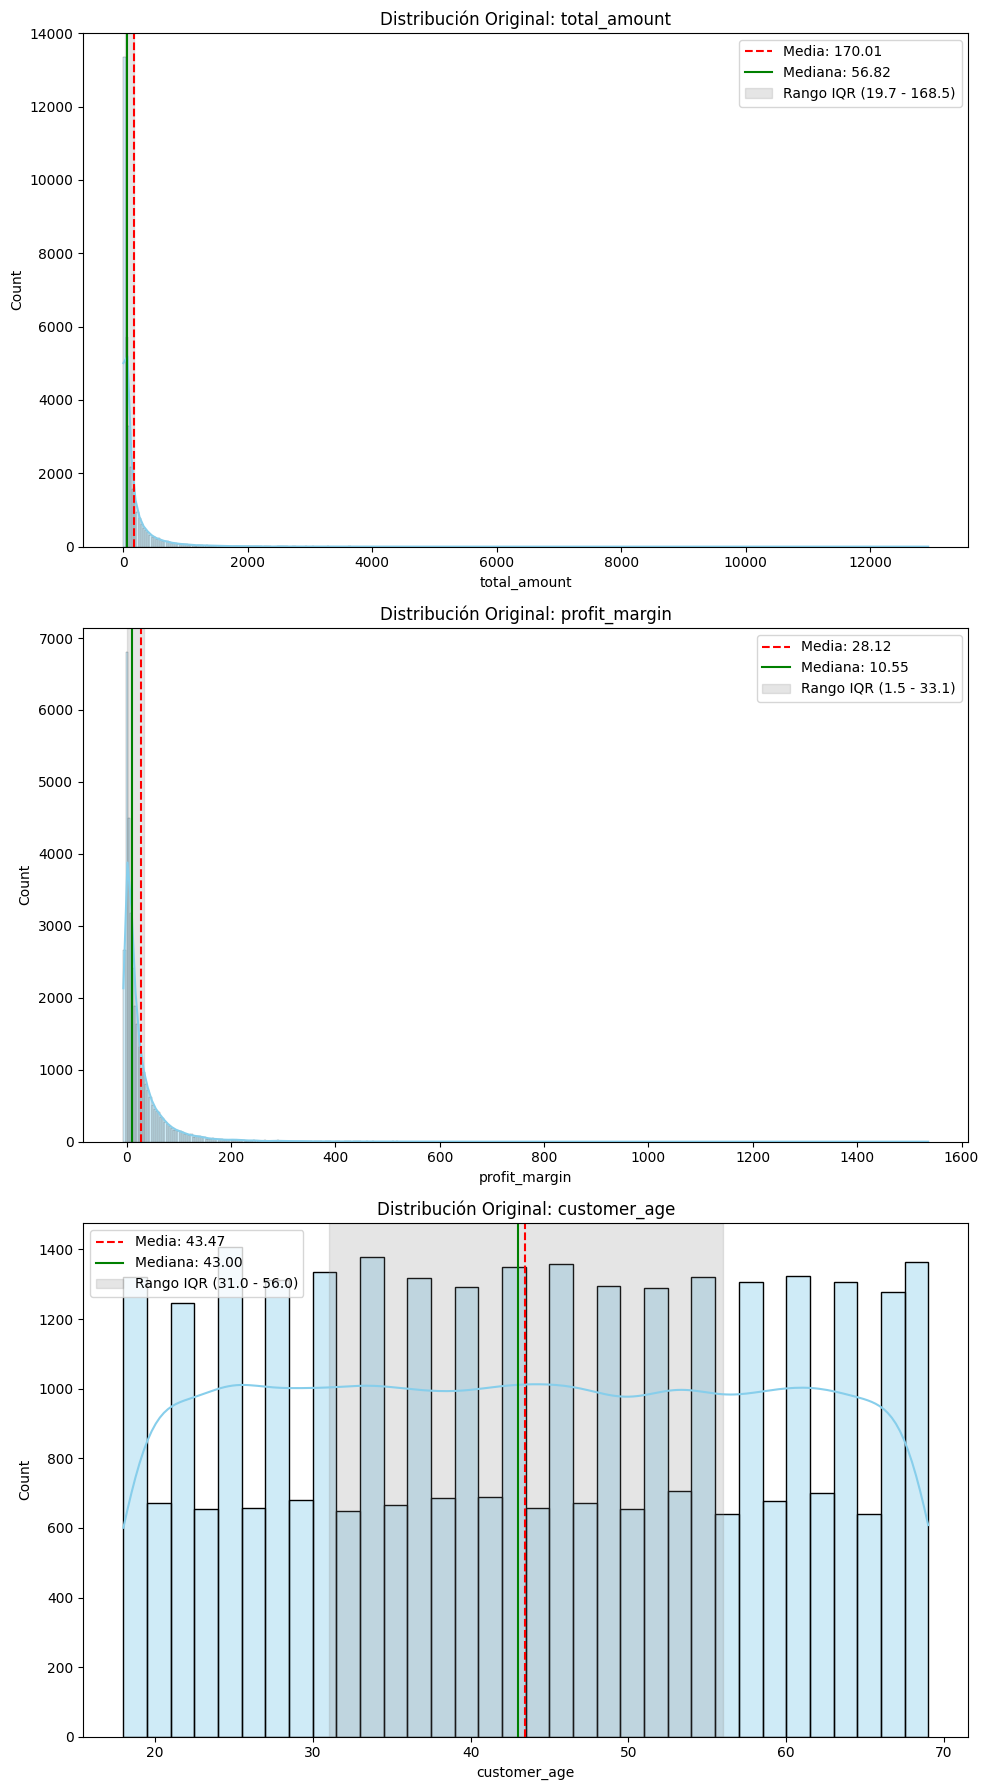

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

for i, col in enumerate(stats_df):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue', alpha=0.4)
    
    #Media y Mediana
    mean_val = df[col].mean()
    median_val = df[col].median()
    q1, q3 = df[col].quantile([0.25, 0.75])
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
    
    # Sombreado del IQR (zona central 50%)
    axes[i].axvspan(q1, q3, color='gray', alpha=0.2, label=f'Rango IQR ({q1:.1f} - {q3:.1f})')
    
    axes[i].set_title(f'Distribución Original: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [5]:
#LIMPIEZA
df_clean = df.copy()

for col in ['total_amount', 'profit_margin']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Filtrado
    df_clean = df_clean[(df_clean[col] >= limite_inferior) & (df_clean[col] <= limite_superior)]

filas_eliminadas = len(df) - len(df_clean)

print(f"- Filas originales: {len(df)}")
print(f"- Filas eliminadas (atípicos): {filas_eliminadas}")
print(f"- Filas restantes en DF limpio: {len(df_clean)}")

- Filas originales: 34500
- Filas eliminadas (atípicos): 5822
- Filas restantes en DF limpio: 28678


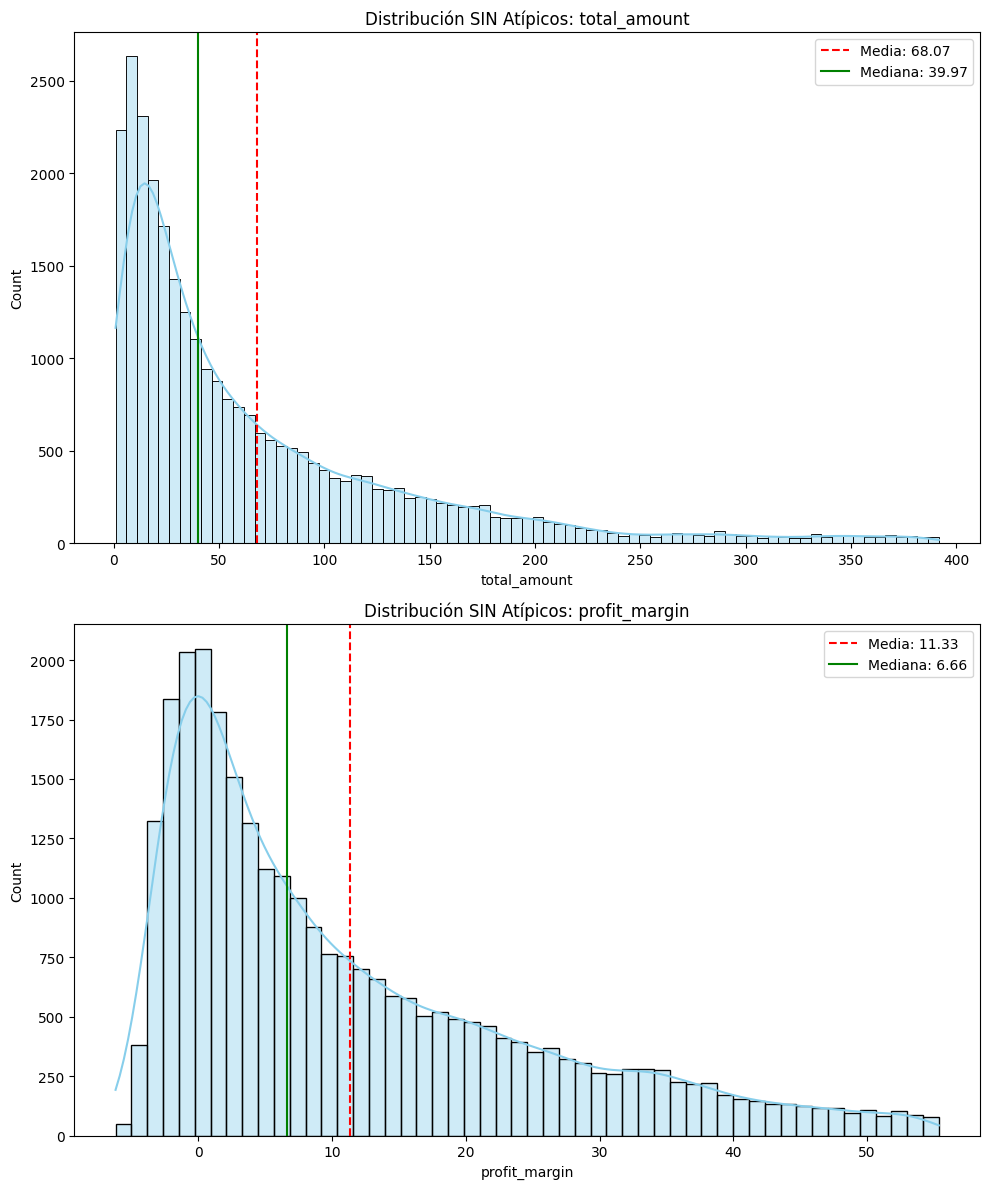

In [6]:
#filtramos solo las primeras columnas, ya que "customer_age" no contiene tanta variacion
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

for i, col in enumerate(['total_amount', 'profit_margin']):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='skyblue', alpha=0.4)
    
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')
    
    axes[i].set_title(f'Distribución SIN Atípicos: {col}')
    axes[i].legend()

plt.tight_layout()
plt.show()

**total_amount:** Inicialmente presenta un sesgo positivo (a la derecha) evidente. La media suele estar por encima de la mediana debido a que unos pocos pedidos de valor muy alto "estiran" la cola. Tras la limpieza (punto 4), la distribución se vuelve más compacta, aunque es difícil que sea perfectamente normal, ya que las ventas suelen concentrarse en tickets bajos.


**profit_margin:** Suele ser la más errática. Dependiendo del dataset, puede mostrar sesgo si hay muchos productos con poco margen. Al eliminar atípicos, observamos una forma más simétrica, pero los "huecos" en el histograma podrían indicar categorías de productos con márgenes fijos muy marcados.


**customer_age:** Es la que más se aproxima a una distribución uniforme o normal (aunque no la hayamos limpiado). En datos demográficos, es común ver una distribución más equilibrada a menos que la tienda esté muy nicho en una edad concreta.


**Comparación 2 vs 4:** En el punto 4, al eliminar los valores extremos (outliers), el eje X se reduce significativamente. Esto permite que la "montaña" de la distribución se vea con mucho más detalle, eliminando el "ruido" de ventas extraordinarias que no representan el comportamiento habitual del negocio.

# Bloque 3: Análisis Univariante de variables categóricas (1.5 pts)

Vamos a analizar las variables categóricas:
+ category: Para entender qué tipo de productos dominan el mercado.
+ payment_method: Fundamental para ver hábitos financieros y posibles comisiones.
+ region: Para identificar áreas geográficas con mayor volumen de negocio.
+ returned: Vital para analizar la tasa de fracaso de las ventas (logística inversa)

__En celdas de código independientes:__

1. Calcular y mostrar de cada variable: Moda, valores únicos.

2. Frecuencia de Categorías: Calcular el número de pedidos por cada category y mostrarlo en un gráfico de barras y de tartas.
   
3. Preferencia de Pago: Crear un gráfico de tarta para visualizar la distribución porcentual de los payment_method.

4. Análisis de Devoluciones por Región: Crear un gráfico de barras apilado o agrupado que muestre la cantidad de productos devueltos (returned) frente a los no devueltos, desglosado por region.

5. Responder en __markdown__ las categorias dominantes, porcentaje de devoluciones por región y conclusiones obtenidas.

In [7]:
cat_vars = ['category', 'payment_method', 'region', 'returned']

for col in cat_vars:
    moda = df[col].mode()[0]
    unicos = df[col].nunique()
    print(f"Variable: {col}")
    print(f" - Moda: {moda}")
    print(f" - Nº de valores únicos: {unicos}")
    print(f" - Valores: {df[col].unique()}\n")


Variable: category
 - Moda: Fashion
 - Nº de valores únicos: 7
 - Valores: <StringArray>
['Home', 'Grocery', 'Electronics', 'Beauty', 'Fashion', 'Toys', 'Sports']
Length: 7, dtype: str

Variable: payment_method
 - Moda: Credit Card
 - Nº de valores únicos: 6
 - Valores: <StringArray>
['Credit Card', 'UPI', 'COD', 'PayPal', 'Debit Card', 'Wallet']
Length: 6, dtype: str

Variable: region
 - Moda: South
 - Nº de valores únicos: 5
 - Valores: <StringArray>
['West', 'South', 'North', 'East', 'Central']
Length: 5, dtype: str

Variable: returned
 - Moda: No
 - Nº de valores únicos: 2
 - Valores: <StringArray>
['No', 'Yes']
Length: 2, dtype: str



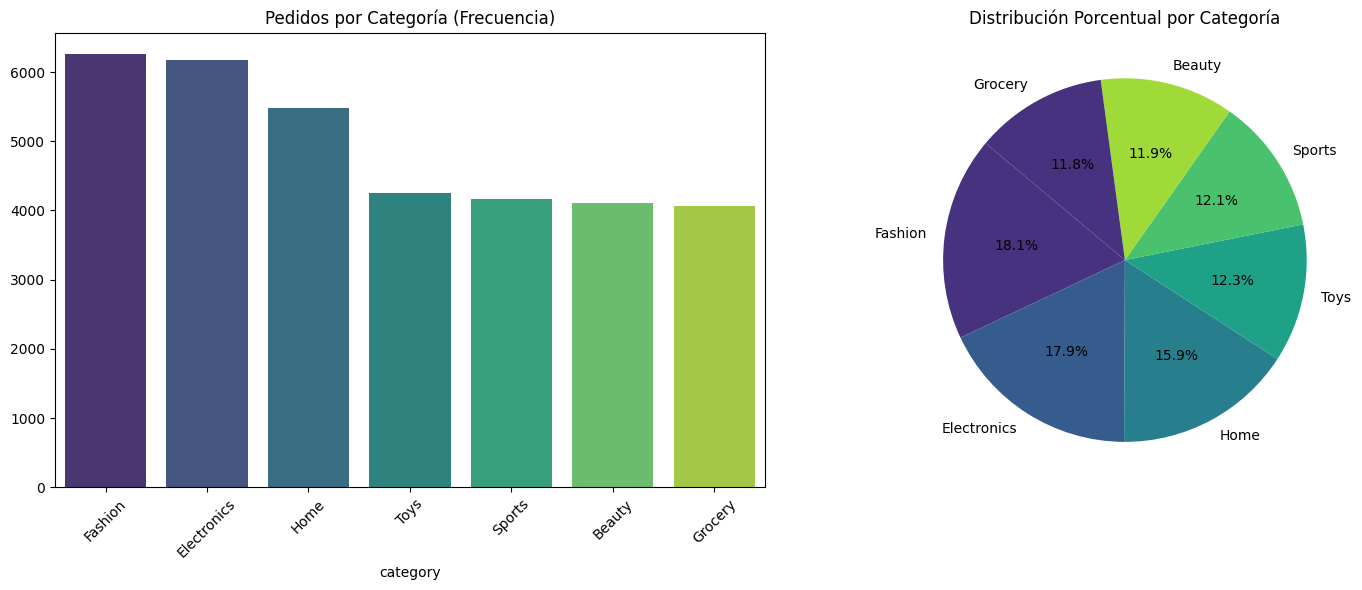

In [8]:
cat_counts = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de barras
#Asignamos 'x' a 'hue', desactivamos la leyenda y usamos el mismo palette para que no salte error de deprecated
sns.barplot(x=cat_counts.index, y=cat_counts.values, ax=axes[0], hue=cat_counts.index, palette='viridis', legend=False)
axes[0].set_title('Pedidos por Categoría (Frecuencia)')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico de tarta
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis'))
axes[1].set_title('Distribución Porcentual por Categoría')

plt.tight_layout()
plt.show()

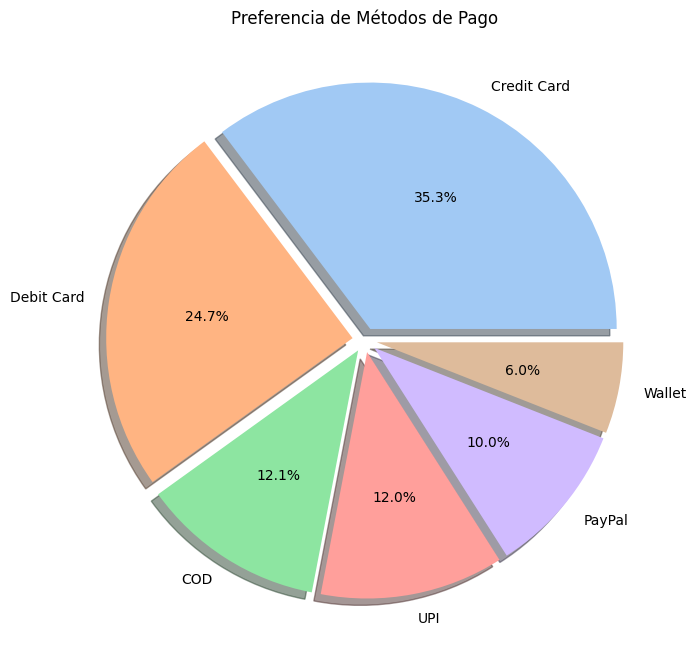

In [9]:
pay_counts = df['payment_method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%', 
        colors=sns.color_palette('pastel'), explode=[0.05]*len(pay_counts), shadow=True)
plt.title('Preferencia de Métodos de Pago')
plt.show()

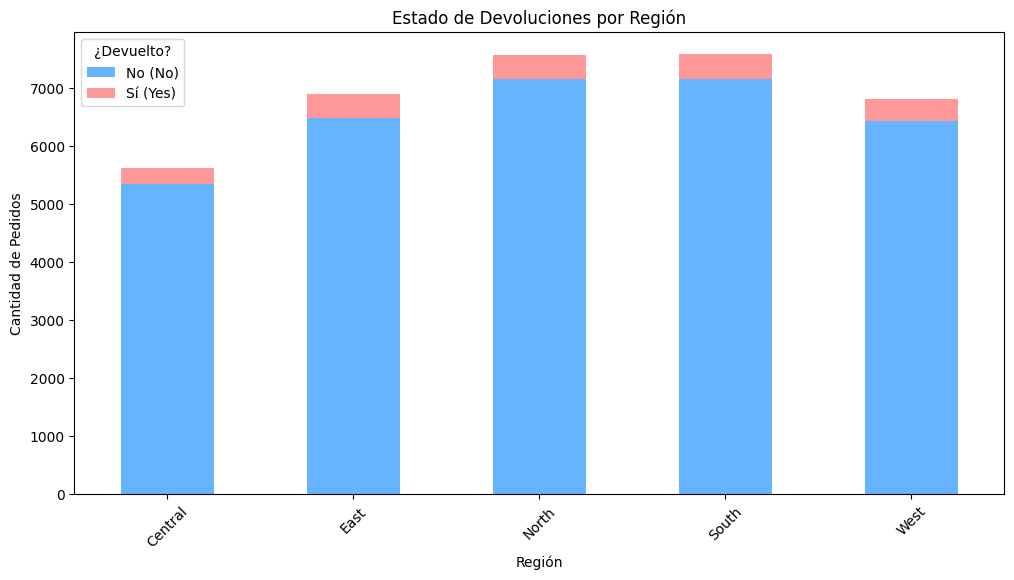

--- % Devoluciones por Región ---


returned,No,Yes
region,,
Central,94.90,5.10
East,94.09,5.91
North,94.64,5.36
South,94.32,5.68
West,94.55,5.45


In [10]:
#tabla de contingencia
region_returns = pd.crosstab(df['region'], df['returned'])

# Gráfico de barras apilado
region_returns.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#66b3ff','#ff9999'])

plt.title('Estado de Devoluciones por Región')
plt.xlabel('Región')
plt.ylabel('Cantidad de Pedidos')
plt.legend(title='¿Devuelto?', labels=['No (No)', 'Sí (Yes)'])
plt.xticks(rotation=45)
plt.show()

#Mostrar tabla de porcentajes para el análisis de la respuesta 5
print("--- % Devoluciones por Región ---")
region_pct = pd.crosstab(df['region'], df['returned'], normalize='index') * 100
display(region_pct.round(2))

Conclusiones del Análisis Categórico


**Categorías Dominantes:** En este dataset las categorías como Fashion o Electronics lideran


**Hábitos de Pago:** El método preferido es Credit Card. La empresa podría negociar mejores comisiones con las pasarelas de pago.


**Logística Inversa (Devoluciones) por Región:**"La región South presenta el mayor volumen de ventas, pero la región East tiene una tasa de devolución porcentualmente más alta, lo que podría indicar problemas con la empresa de transporte local o expectativas del producto."


**Conclusión General:** El perfil del negocio muestra una fuerte concentración en la categoría "Fashion", con altas ventas en la region South y una salud logística es Muy Buena dado que el porcentaje global de devoluciones es del 5,5%.

# Bloque 4: Análisis de Segmentación y ANOVA sobre variable método de pago (2 pts)

Sobre el DF original.

__En celdas de código independientes:__

1. Boxplots: Visualizar el beneficio (profit_margin) según __método de pago__.
   
2. Analizar Outliers: Calcula y muestra el límite superior que marca cada outliter para cada medio de pago y cuántos outliers tiene cada medio.

3. Limpia los outliers calculados anteriormente en una copia del DF.

4. Ejecutar un test ANOVA sobre el DF limpio para determinar si el método de pago influye significativamente en el beneficio.

5. Comenta en __markdown__ si hay diferencias.

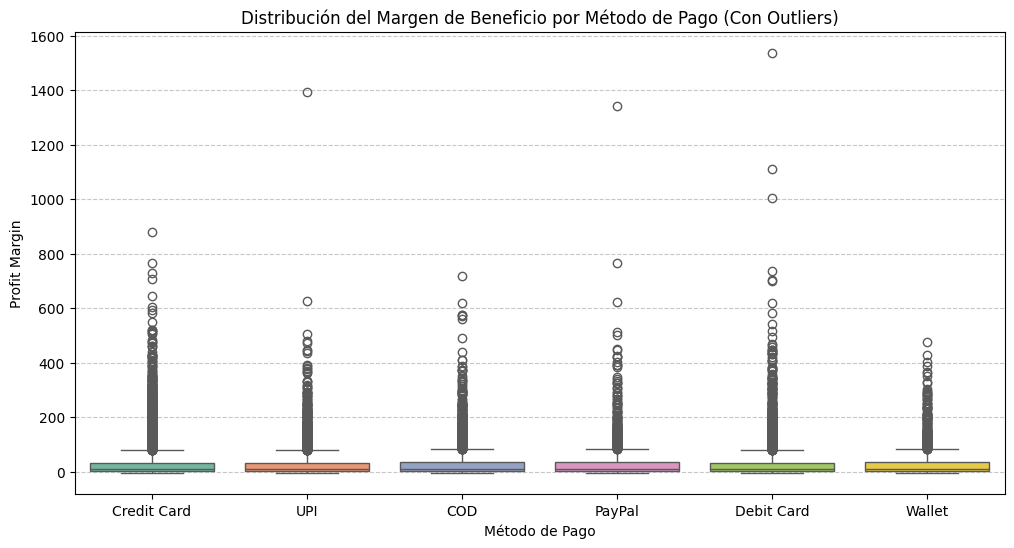

In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='payment_method', y='profit_margin', data=df, hue='payment_method', palette='Set2', legend=False)

plt.title('Distribución del Margen de Beneficio por Método de Pago (Con Outliers)')
plt.xlabel('Método de Pago')
plt.ylabel('Profit Margin')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
methods = df['payment_method'].unique()
outlier_report = []

for method in methods:
    data_method = df[df['payment_method'] == method]['profit_margin']
    
    Q1 = data_method.quantile(0.25)
    Q3 = data_method.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    

    outliers = data_method[data_method > limite_superior]
    
    outlier_report.append({
        'Método': method,
        'Límite Superior': round(limite_superior, 2),
        'Cant. Outliers': len(outliers)
    })


df_outlier_report = pd.DataFrame(outlier_report)
display(df_outlier_report)

,Método,Límite Superior,Cant. Outliers
0,Credit Card,80.34,1079
1,UPI,79.19,383
2,COD,81.47,340
3,PayPal,82.82,273
4,Debit Card,80.11,773
5,Wallet,82.44,175


In [13]:
# Crear copia para el test estadístico
df_anova = pd.DataFrame()

for method in methods:
    data_method = df[df['payment_method'] == method].copy()
    
    lim_sup = Q3 + 1.5 * IQR
    lim_inf = Q1 - 1.5 * IQR # Por si hubiera pérdidas extremas
    
    # Filtrar este segmento y añadirlo al nuevo DF
    clean_segment = data_method[(data_method['profit_margin'] >= lim_inf) & 
                                (data_method['profit_margin'] <= lim_sup)]
    df_anova = pd.concat([df_anova, clean_segment])

print(f"Filas originales: {len(df)} | Filas tras limpiar por grupo: {len(df_anova)}")

Filas originales: 34500 | Filas tras limpiar por grupo: 31568


In [14]:
modelo = smf.ols("profit_margin ~ payment_method", data=df).fit()
anova_resultado = sm.stats.anova_lm(modelo)

print(anova_resultado)

                     df        sum_sq      mean_sq         F    PR(>F)
payment_method      5.0  1.229333e+03   245.866588  0.086362  0.994407
Residual        34494.0  9.820145e+07  2846.913884       NaN       NaN


El análisis ANOVA muestra un p-valor de 0.994, muy superior al umbral de significancia de 0.05. Por lo tanto, no se rechaza la hipótesis nula y se concluye que el método de pago no tiene un efecto significativo sobre el margen de beneficio. La rentabilidad es consistente independientemente de cómo decida pagar el cliente.

# Bloque 5: Análisis de Segmentación y ANOVA sobre variable category (2 pts)

Sobre el DF original.

__En celdas de código independientes:__

1. Boxplots: Visualizar el beneficio (profit_margin) según la __categoría__ del producto.
   
2. Analizar Outliers: Calcula y muestra el límite superior que marca cada outliter para cada categoría y cuántos outliers tiene una.

3. Limpia los outliers calculados anteriormente en una copia del DF.

4. Vuelve a mostrar el Boxplot sin los outliers(usa el parámetro showfliers=False para que no se vean de nuevo los atípicos)

5. Ejecutar un test ANOVA sobre el DF limpio para determinar si la categoría influye significativamente en el beneficio.

6. Ejecutar el Test de Tukey.

7. Comenta en __markdown__ si hay diferencias y categorías más importantes.

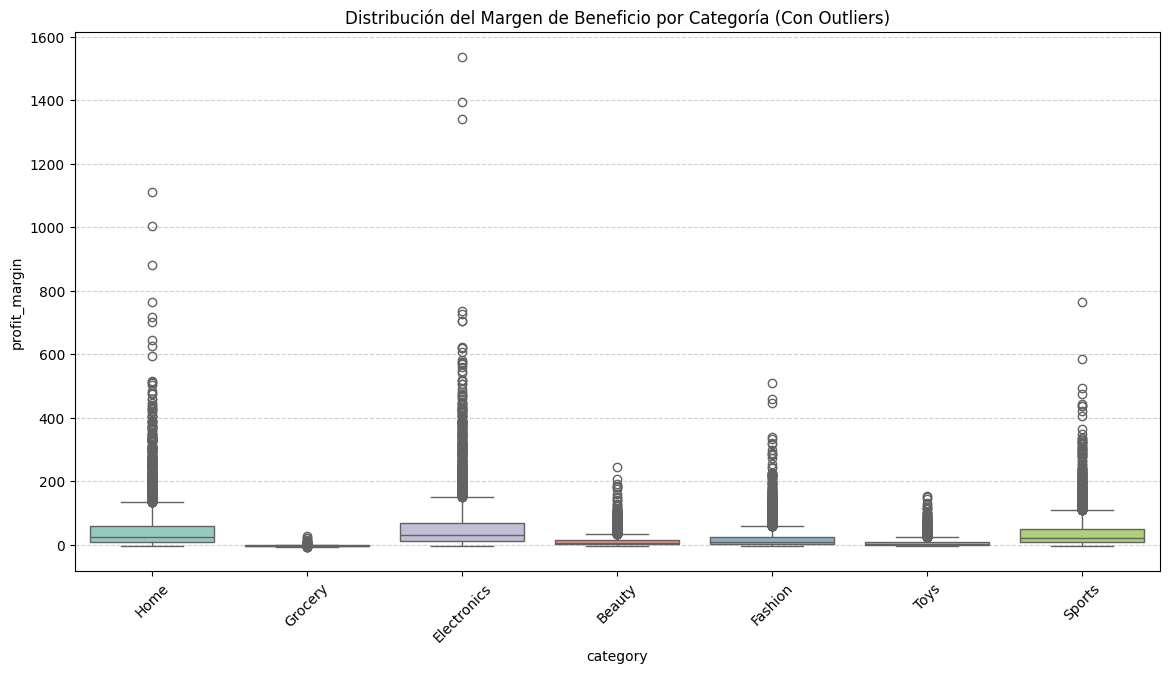

In [15]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='category', y='profit_margin', data=df, hue='category', palette='Set3', legend=False)

plt.title('Distribución del Margen de Beneficio por Categoría (Con Outliers)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [16]:
categories = df['category'].unique()
outlier_cat_report = []

for cat in categories:
    data_cat = df[df['category'] == cat]['profit_margin']
    
    Q1 = data_cat.quantile(0.25)
    Q3 = data_cat.quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    num_outliers = len(data_cat[data_cat > limite_superior])
    
    outlier_cat_report.append({
        'Categoría': cat,
        'Límite Superior': round(limite_superior, 2),
        'Cant. Outliers': num_outliers
    })

df_outlier_cat = pd.DataFrame(outlier_cat_report)
display(df_outlier_cat)

,Categoría,Límite Superior,Cant. Outliers
0,Home,135.21,399
1,Grocery,0.94,85
2,Electronics,151.95,455
3,Beauty,34.74,330
4,Fashion,59.83,439
5,Toys,24.99,326
6,Sports,110.15,300


In [17]:
df_category_clean = pd.DataFrame()

for cat in categories:
    data_cat = df[df['category'] == cat].copy()
    
    Q1 = data_cat['profit_margin'].quantile(0.25)
    Q3 = data_cat['profit_margin'].quantile(0.75)
    IQR = Q3 - Q1
    
    lim_sup = Q3 + 1.5 * IQR
    lim_inf = Q1 - 1.5 * IQR
    
    # Filtrado por categoría
    clean_segment = data_cat[(data_cat['profit_margin'] >= lim_inf) & 
                             (data_cat['profit_margin'] <= lim_sup)]
    
    df_category_clean = pd.concat([df_category_clean, clean_segment])

print(f"Filas originales: {len(df)} | Filas tras limpieza: {len(df_category_clean)}")

Filas originales: 34500 | Filas tras limpieza: 32161


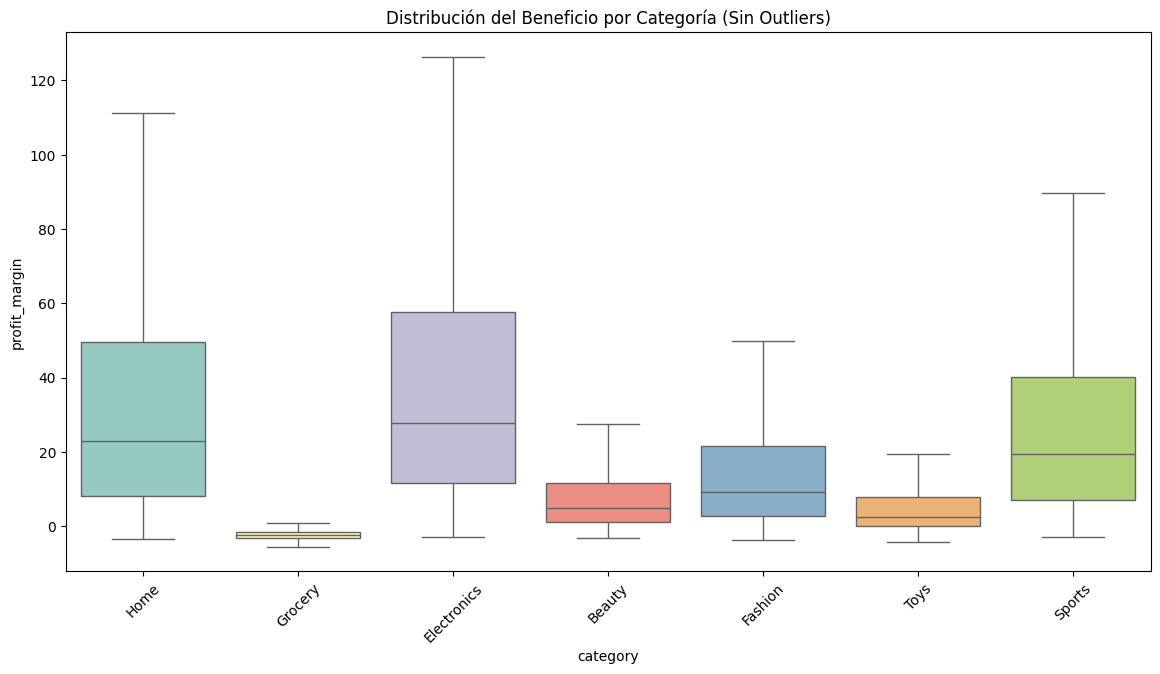

In [18]:
plt.figure(figsize=(14, 7))
# Usamos el DF limpio y reforzamos con showfliers=False
sns.boxplot(x='category', y='profit_margin', data=df_category_clean, 
            hue='category', palette='Set3', showfliers=False, legend=False)

plt.title('Distribución del Beneficio por Categoría (Sin Outliers)')
plt.xticks(rotation=45)
plt.show()

In [19]:
modelo = smf.ols("profit_margin ~ category", data=df).fit()
anova_resultado = sm.stats.anova_lm(modelo)

print(anova_resultado)


               df        sum_sq       mean_sq           F  PR(>F)
category      6.0  1.419548e+07  2.365913e+06  971.433651     0.0
Residual  34493.0  8.400720e+07  2.435486e+03         NaN     NaN


In [20]:
tukey_cat = pairwise_tukeyhsd(endog=df_category_clean['profit_margin'], 
                              groups=df_category_clean['category'], 
                              alpha=0.05)

print(tukey_cat.summary())

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper   reject
---------------------------------------------------------------
     Beauty Electronics  31.3905   0.0  29.9933  32.7876   True
     Beauty     Fashion   6.4842   0.0   5.0914    7.877   True
     Beauty     Grocery -10.0261   0.0 -11.5411   -8.511   True
     Beauty        Home  25.3989   0.0  23.9674  26.8304   True
     Beauty      Sports   19.811   0.0  18.2867  21.3353   True
     Beauty        Toys  -2.8013   0.0  -4.3208  -1.2818   True
Electronics     Fashion -24.9063   0.0 -26.1468 -23.6658   True
Electronics     Grocery -41.4165   0.0 -42.7928 -40.0402   True
Electronics        Home  -5.9916   0.0  -7.2753  -4.7078   True
Electronics      Sports -11.5795   0.0 -12.9659  -10.193   True
Electronics        Toys -34.1918   0.0 -35.5729 -32.8106   True
    Fashion     Grocery -16.5103   0.0 -17.8822 -15.1383   True
    Fashion        Home  18.9147   0.0  

A diferencia de los métodos de pago, donde la estrategia es irrelevante, la gestión del catálogo por categorías es el motor de la rentabilidad.

La empresa debe ser consciente de que vender un producto de Electronics genera, de media, 31.39 unidades más de beneficio que uno de Beauty y casi 41 unidades más que uno de Grocery. Se recomienda priorizar campañas de marketing en Electronics y Home para maximizar el margen global.

# Bloque 6: Análisis Bivariante - Relaciones de 2 variables (1.5 pts)

__En celdas de código independientes:__

1. Correlación: Matriz de correlación y visualización con un Heatmap de Seaborn de todas las variables numéricas.

2. Dispersión: Gráfico de puntos (Scatter plot) con recta de regresión entre los 3 pares más correlacionados.

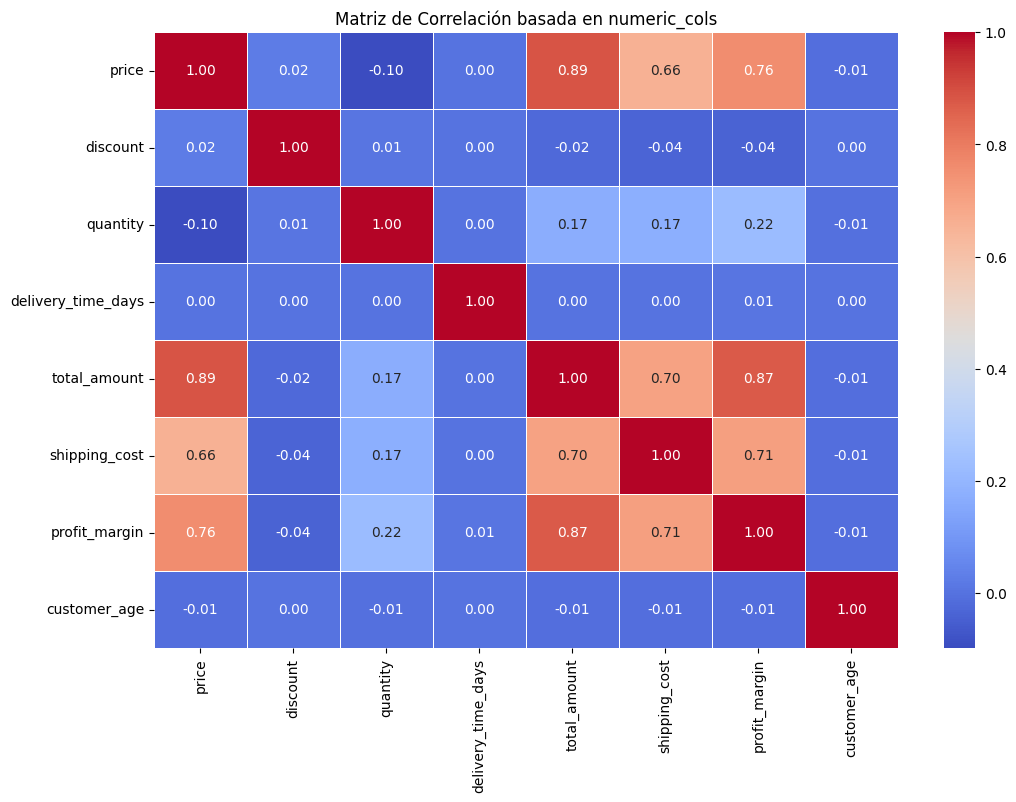

In [21]:
#Creamos una matriz filtrando por la lista que creamos al princpio
matriz_corr = df_category_clean[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriz de Correlación basada en numeric_cols')
plt.show()

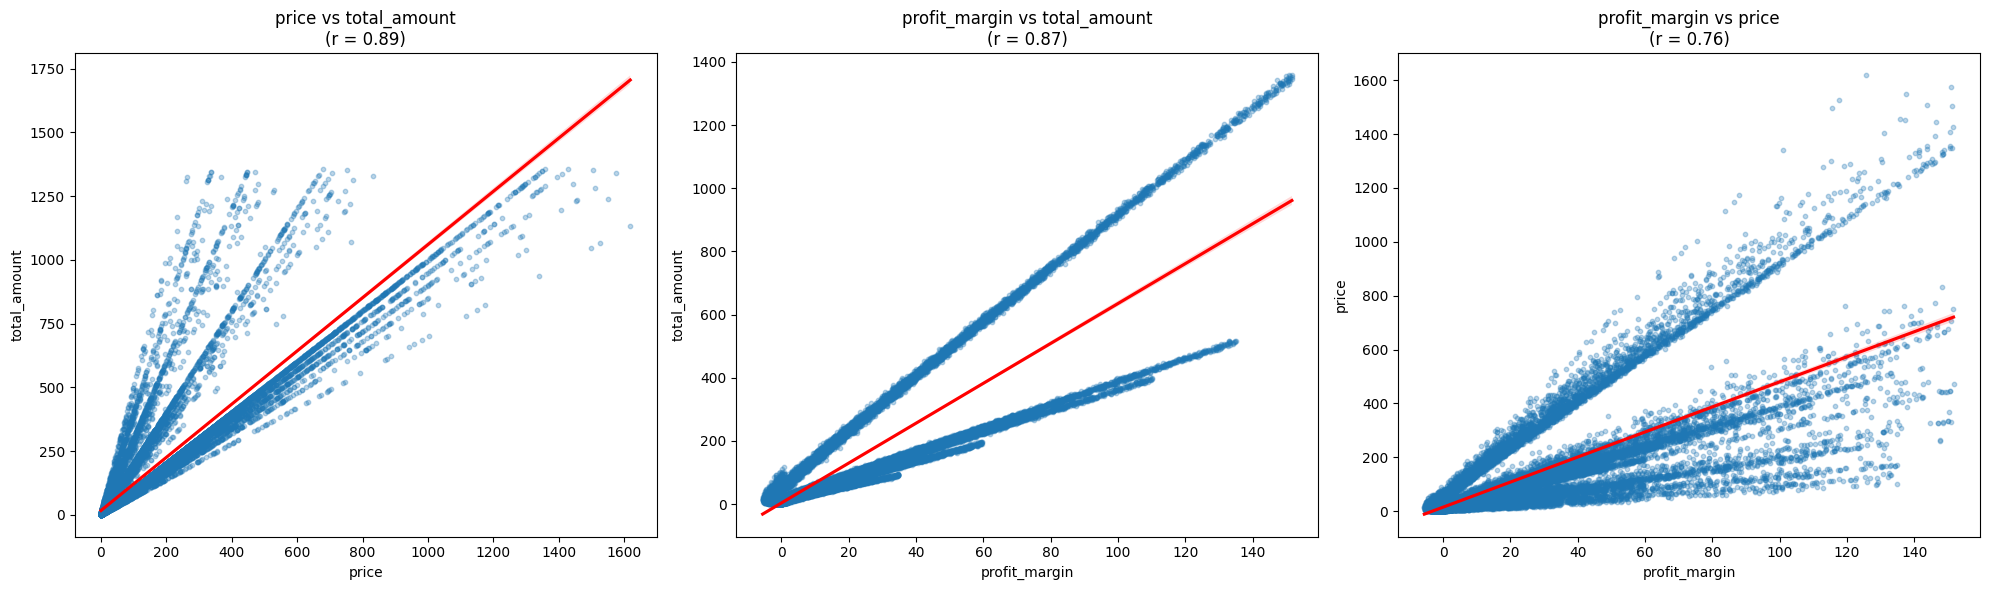

In [ ]:
# Definimos los pares basados en la grafic anterior y los resultados de la matriz

pares_correlacionados = [
    ('price', 'total_amount'),
    ('profit_margin', 'total_amount'),
    ('profit_margin', 'price')
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (var_x, var_y) in enumerate(pares_correlacionados):
    sns.regplot(x=var_x, y=var_y, data=df_category_clean, 
                ax=axes[i], 
                scatter_kws={'alpha':0.3, 's':10}, 
                line_kws={'color':'red'})
    
    # Calculamos la correlación específica para el título
    r = df_category_clean[var_x].corr(df_category_clean[var_y])
    axes[i].set_title(f'{var_x} vs {var_y}\n(r = {r:.2f})')

plt.tight_layout()
plt.show()

# Bloque 7: Análisis de Series Temporales (1.5 pts)

__En celdas de código independientes:__

1. Tendencia: 3 gráfico de líneas diferentes para mostrar la evolución a lo largo del tiempo: las ventas diarias (items), ingresos (total_amount) y margen (profit_margin). Primero debes agrupar datos por día. 

2. Suavizado: Aplicar una media móvil de 30 días para ver la tendencia sin ruido.

3. Agrupar las ventas por mes y graficar con barras. 3 Gráficos: ventas, ignresos y margen.

4. Analiza los datos mostrados en una celda __markdown__.

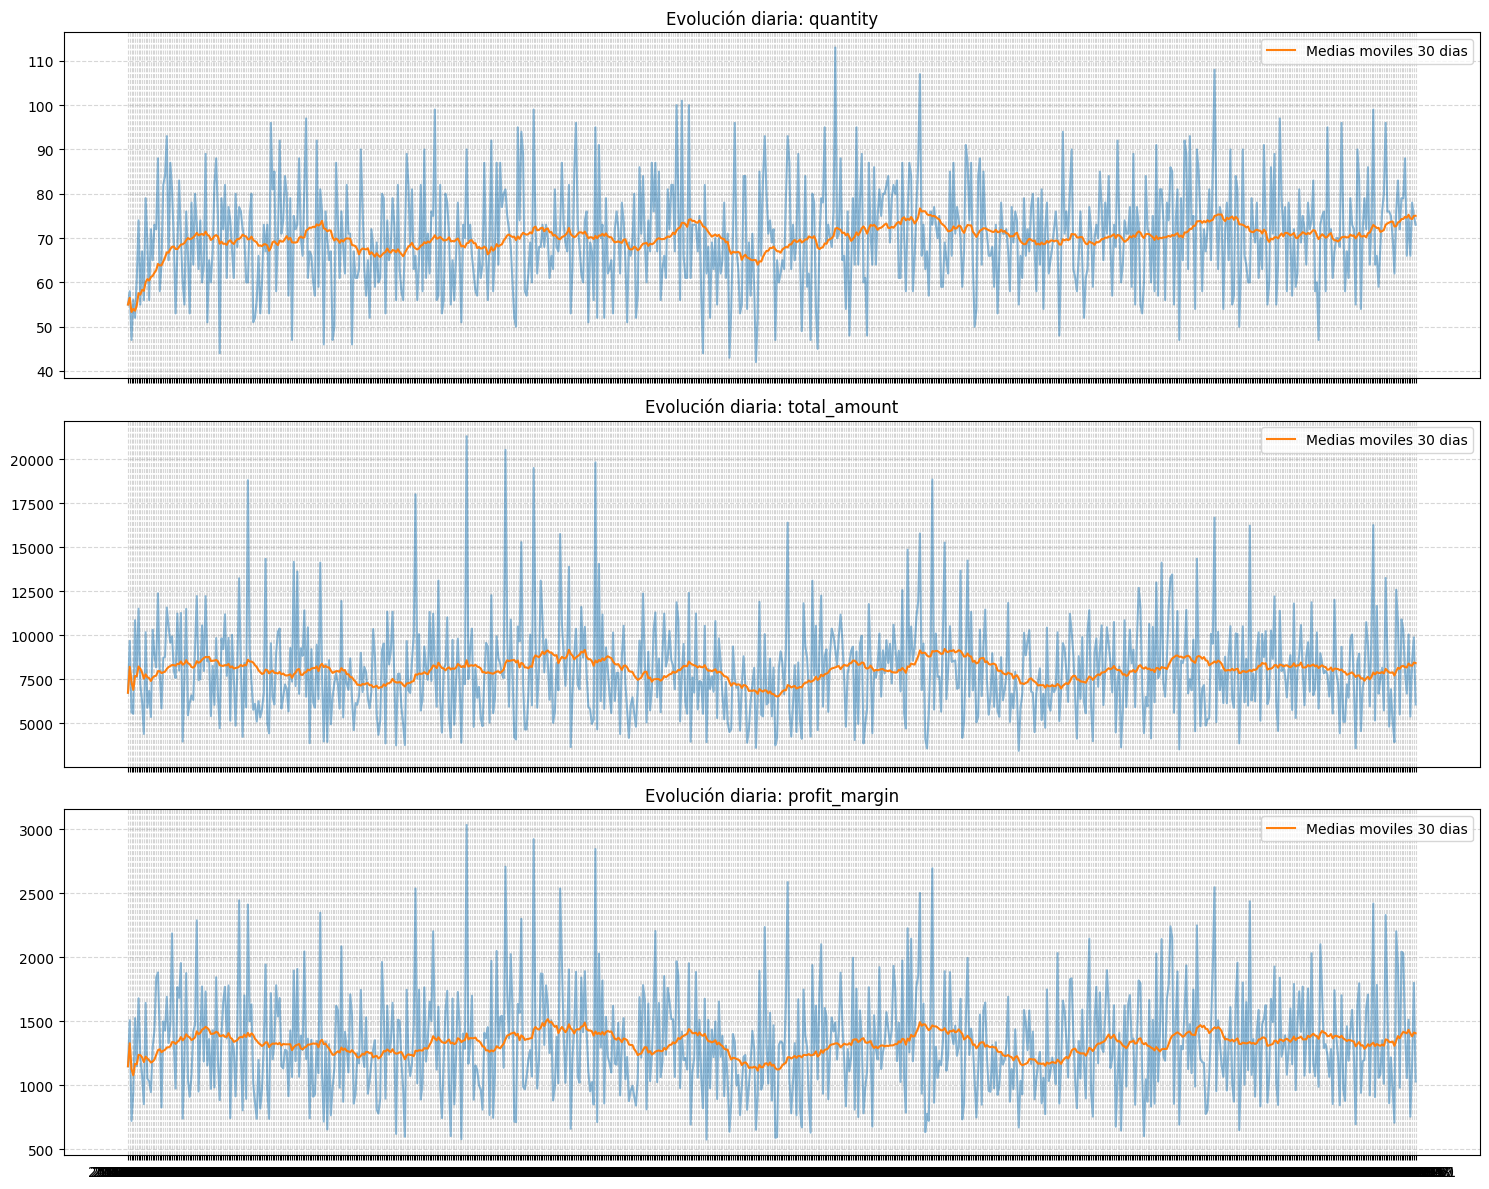

In [28]:
daily_df = df.groupby('order_date').agg({
    'quantity': 'sum',
    'total_amount': 'sum',
    'profit_margin': 'sum'
})

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
metrics = ['quantity', 'total_amount', 'profit_margin']

for i, col in enumerate(metrics):
    axes[i].plot(daily_df.index, daily_df[col], alpha=0.5)
    media = daily_df[col].rolling(window= 30, min_periods = 1).mean()
    axes[i].plot(media, label="Medias moviles 30 dias")
    axes[i].set_title(f'Evolución diaria: {col}')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

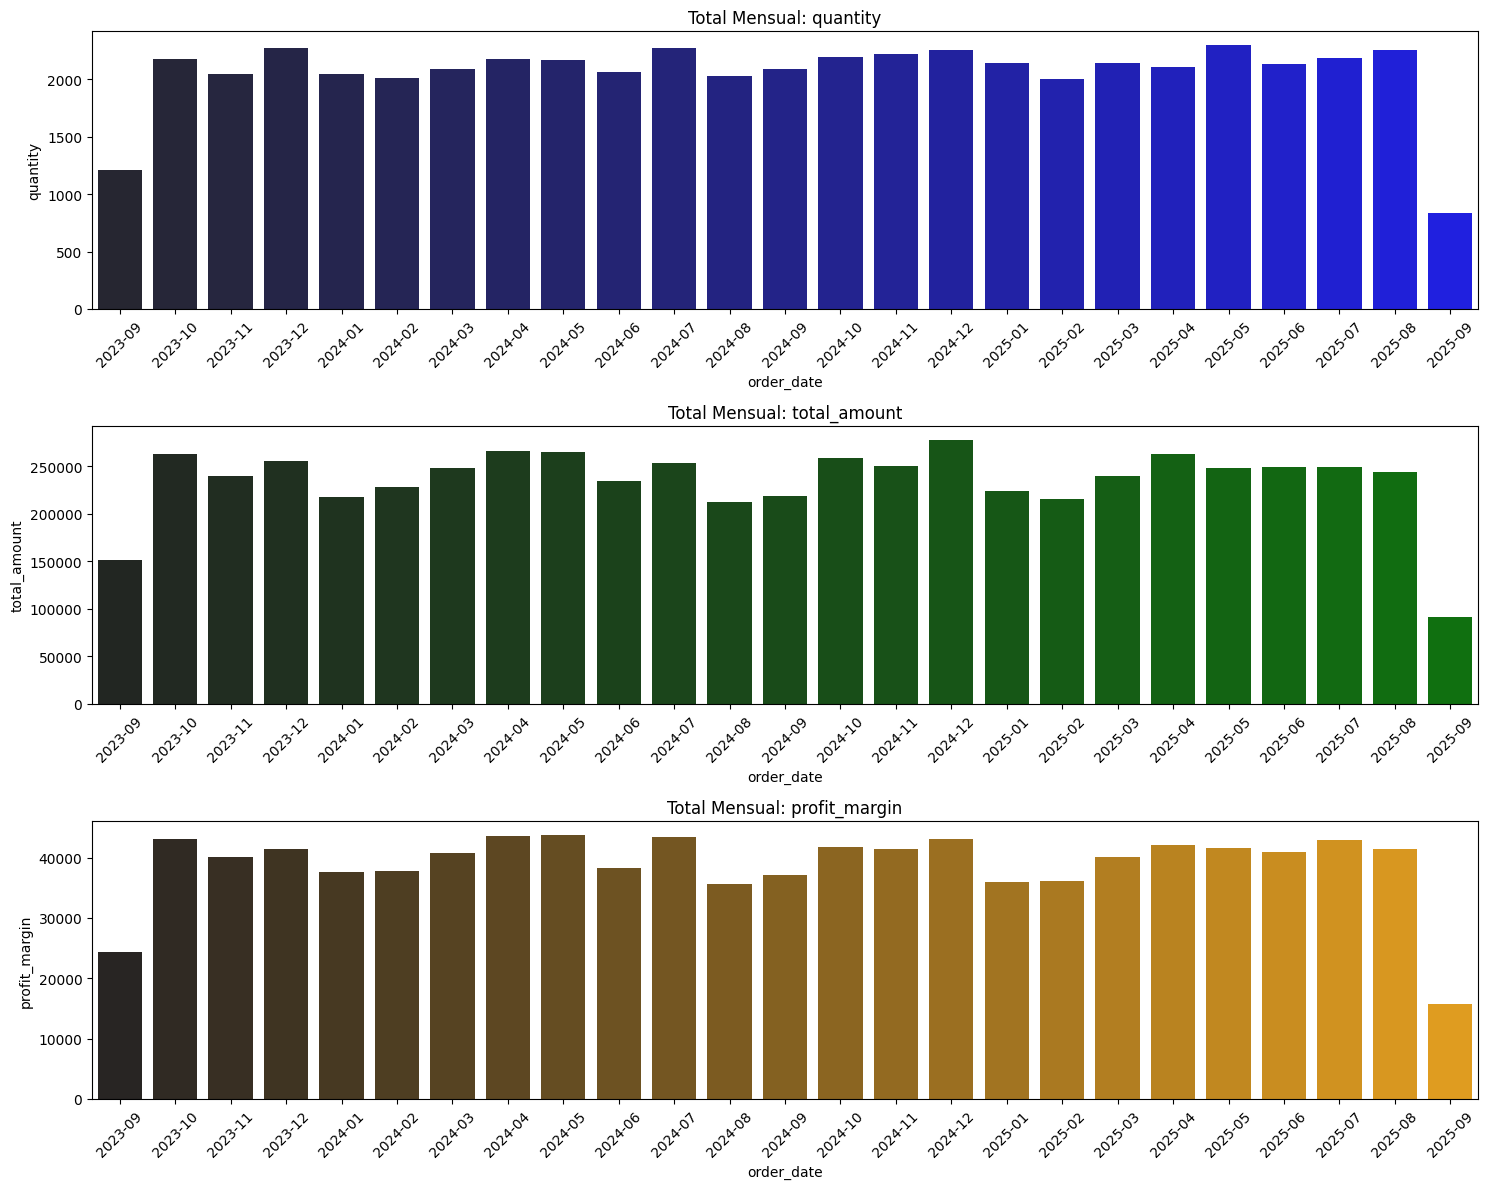

In [ ]:
#aqui fue usado un LLM para encontrar un error de resample, he decidido
#dejar los comentarios por si vuelve a ocurrir

# 1. Aseguramos el tipo de dato
df['order_date'] = pd.to_datetime(df['order_date'])

# 2. Hacemos una copia para no alterar el original y establecemos el índice
df_temp = df.set_index('order_date')

# 3. Ahora el resample funcionará correctamente
monthly_df = df_temp.resample('ME').agg({
    'quantity': 'sum',
    'total_amount': 'sum',
    'profit_margin': 'sum'
})

# 4. Graficamos
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
metrics = ['quantity', 'total_amount', 'profit_margin']
colors = ['dark:blue', 'dark:green', 'dark:orange']

for i, col in enumerate(metrics):
    sns.barplot(x=monthly_df.index.strftime('%Y-%m'), y=monthly_df[col], 
                ax=axes[i], palette=colors[i], hue=monthly_df.index, legend=False)
    axes[i].set_title(f'Total Mensual: {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()